In [1]:
import cv2
import gdown
import os
import matplotlib.pyplot as plt
import numpy as np

In [24]:
def img_details(name,img,s=None,pos=None,cmap=None,show=True):
  if s is not None:
    plt.subplot(s[0],s[1],pos)
    show = False

  if cmap is not None:
      plt.imshow(img,cmap=cmap)
  else:
      plt.imshow(img)

  plt.title(f'{name}{img.shape}')
  plt.tight_layout()

  if show is True:
      plt.show()

In [17]:
def read_img(path):

    file_id = path.split('/d/')[1].split('/')[0]
    dest = 'img.jpg'
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url,output=dest,quiet=False)

    img = cv2.imread('img.jpg',cv2.IMREAD_GRAYSCALE)

    return img

In [19]:
img1 = read_img(r'https://drive.google.com/file/d/1IR-TdzKfzvEsWIcWbFjEewGkiGYe_WOi/view?usp=sharing')
img2 = read_img(r'https://drive.google.com/file/d/1aRkiHJ2Q7T9TnowHchLB1R9lj4BFrQCK/view?usp=drive_link')

Downloading...
From: https://drive.google.com/uc?id=1IR-TdzKfzvEsWIcWbFjEewGkiGYe_WOi
To: /content/img.jpg
100%|██████████| 245k/245k [00:00<00:00, 9.32MB/s]
Downloading...
From: https://drive.google.com/uc?id=1aRkiHJ2Q7T9TnowHchLB1R9lj4BFrQCK
To: /content/img.jpg
100%|██████████| 38.8k/38.8k [00:00<00:00, 32.4MB/s]


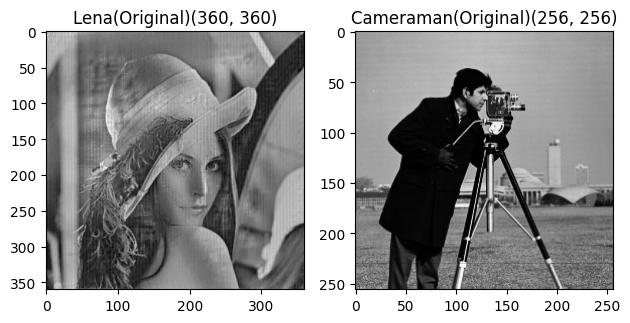

In [26]:
s = (1,2)
img_details('Lena(Original)',img1,s,1,cmap='gray')
img_details('Cameraman(Original)',img2,s,2,cmap='gray')
plt.show()

# **Hough Transform**

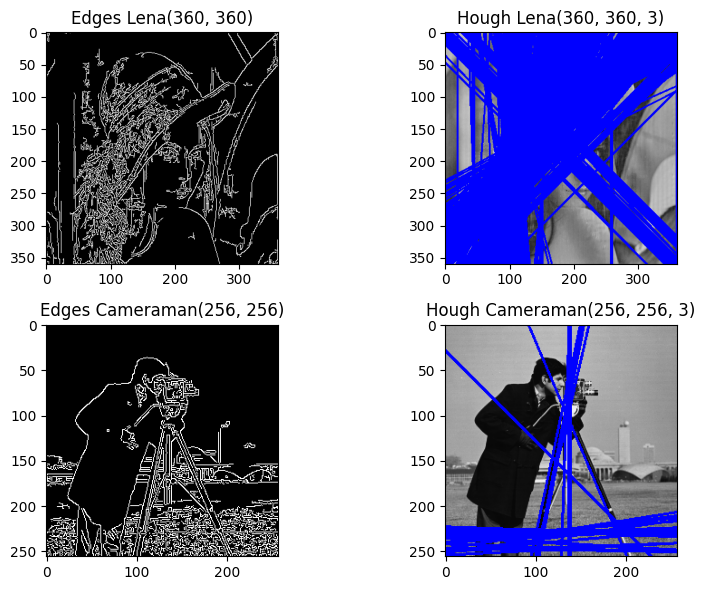

In [27]:
# Canny edge detection parameters
low_threshold = 50
high_threshold = 150

# Apply Canny edge detection
edges1 = cv2.Canny(img1, low_threshold, high_threshold)
edges2 = cv2.Canny(img2, low_threshold, high_threshold)

# Perform Hough Line Transform
lines1 = cv2.HoughLines(edges1, 1, np.pi / 180, threshold=100)
lines2 = cv2.HoughLines(edges2, 1, np.pi / 180, threshold=100)

# Convert grayscale images to BGR to display lines in color
img1_lines = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
img2_lines = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

# Draw lines on img1
if lines1 is not None:
    for line in lines1:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img1_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Draw lines on img2
if lines2 is not None:
    for line in lines2:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img2_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Display the results using img_details
plt.figure(figsize=(12, 6))

img_details("Edges Lena", edges1, s=(2, 2), pos=1, cmap='gray', show=False)
img_details("Hough Lena", img1_lines, s=(2, 2), pos=2, show=False)

img_details("Edges Cameraman", edges2, s=(2, 2), pos=3, cmap='gray', show=False)
img_details("Hough Cameraman", img2_lines, s=(2, 2), pos=4)

plt.show()


# **HARIS CORNER DETECTION**

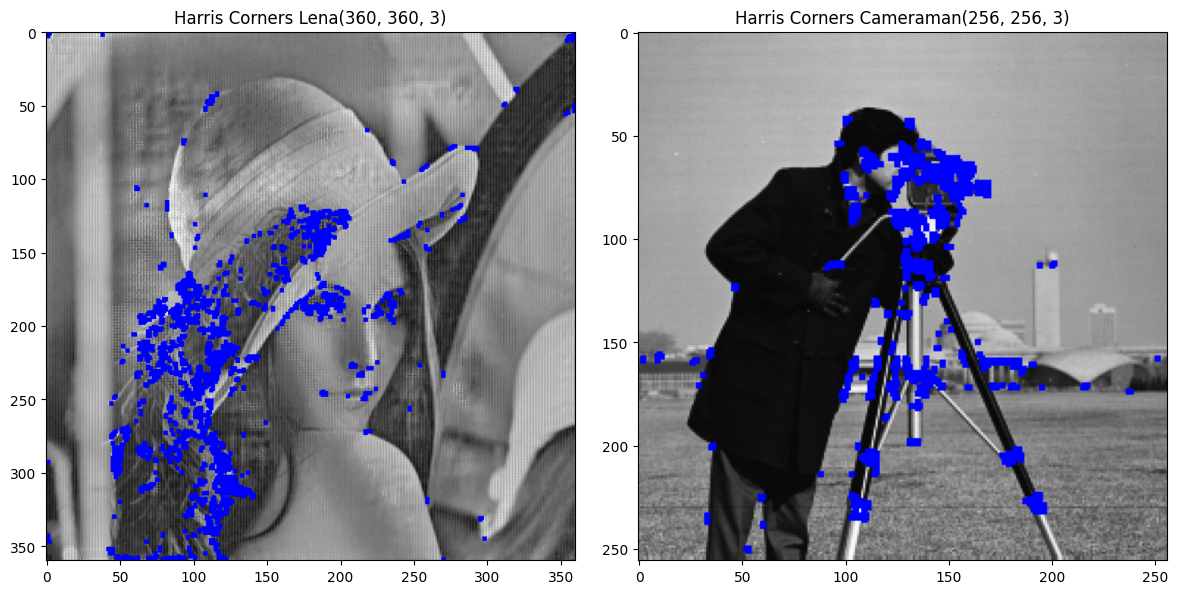

In [28]:
# Convert images to float32 for Harris corner detection
gray1 = np.float32(img1)
gray2 = np.float32(img2)

# Apply Harris Corner Detection
dst1 = cv2.cornerHarris(gray1, blockSize=2, ksize=3, k=0.04)
dst2 = cv2.cornerHarris(gray2, blockSize=2, ksize=3, k=0.04)

# Dilate the corner points to enhance them
dst1_dilated = cv2.dilate(dst1, None)
dst2_dilated = cv2.dilate(dst2, None)

# Copy original images for drawing corners (convert to color for visualization)
img1_corners = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
img2_corners = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)

# Threshold for an optimal value; mark corners in RED
img1_corners[dst1_dilated > 0.01 * dst1_dilated.max()] = [0, 0, 255]
img2_corners[dst2_dilated > 0.01 * dst2_dilated.max()] = [0, 0, 255]

# Display using img_details
plt.figure(figsize=(12, 6))

img_details("Harris Corners Lena", img1_corners, s=(1, 2), pos=1, show=False)
img_details("Harris Corners Cameraman", img2_corners, s=(1, 2), pos=2)

plt.show()
